# The Vavilov Ice Cap surge, inversion on n and the half-width
Following the simple model, we devolped a more complex inversion to find the stress exponent and the half-width that produce the velocity profile model that best fit the data.

## Import packages
Use pgdal env

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from skimage.measure import profile_line
from scipy import ndimage
import matplotlib.gridspec as gridspec

#%matplotlib inline

## Functions

In [2]:
def ice_velocity(u_0, y, w, n, option=0):
    '''
    Calculate the transect velocity knowing the centrale velocity of the profile 
    u_0    --> velocity at the centrer of the profile (at y = 0) 
    y      --> Y vector position along a profile perpendicular to the flow, y = 0 at the center
    w      --> half-width of the profile
    n      --> stress exponent (see Glen's flow law)
    option --> 0 for y = 0 a center, 1 for y = 0 at margin
    '''
    if option == 0:
        u = (1 - (abs(y)/w) ** (n+1)) * u_0
    elif option == 1:
        u = (1 - (abs(1 - y/w)) ** (n+1)) * u_0
    return u

def setup_data(u, x1, x2):
    '''
    Set up needed data for the estimate of velocity
    u_0      --> velocity at the centerline of the profil (y = 0)
    w_model  --> half-width of the model
    y_model  --> Y vector position along a profile perpendicular to the flow, y = 0 at the center
    '''
    u_0 = np.max(u)
    w_model = (-x1+x2)/2
    y_model = np.linspace(-w_model,w_model,int(w_model*2))
    return u_0, y_model, w_model

def moving_avg(data, win_size):
    '''
    Calculate moving average
    data      --> data vector on which you estimate the average
    win_size  --> length of the moving window
    '''
    i = 0
    moving_averages = []
    while i < len(data) - win_size + 1:
        window = data[i : i + win_size]  #select the window
        window_average = round(sum(window) / win_size, 2)  #calculate the mean
        moving_averages.append(window_average)  #fill the new data vector
        i += 1
    return moving_averages


def flow_limits(u, win):
    '''
    Find limits of the flowing ice
    usmooth     --> smoothed version of the velocity profile by averaged moving windows
    ugrad       --> gradient of the smoothed velocity profile to find the fast-flow limits
    idx1, idx2  --> index of the flow limits
    '''
    usmooth = moving_avg(u,win)
    ugrad = np.diff(usmooth)
    idx1 = np.argmax(ugrad)
    idx2 = np.argmin(ugrad)
    return round(idx1), round(idx2)

def L1_norm_residuals(data, model, error):
    '''
    Calculate L1-norm (Manhattan geometry) between data and model
    '''
    curve = data - model / error ** 2
    res = np.nansum(curve) / len(data)
    return res

def L2_norm_residuals(data, model, variance):
    '''
    Calculate L2-norm (Euclidean distance) between data and model
    '''
    # Calculate the misfit with weights (variance)
    weighted_residuals = (data - model) ** 2 / variance
    misfit = np.sqrt(np.nansum(weighted_residuals) / len(data))
    return misfit

def variance_reduction(data, model):
    '''
    Calculate variance reduction
    '''
    res = (data - model) ** 2
    vr = np.sqrt(np.nansum(res)) / np.sqrt(np.nansum(data **2))
    #vr = 1 - (np.nansum(res)/np.nansum(data **2)) to test maybe?
    return vr

def prc_best_model(res, x_list, y_list, prc = 5):
    '''
    Evaluate the x% best models
    '''
    nb10 = round(res.size * prc / 100)                     # Estimate number of couple
    res_list = res.flatten()                               # Convert matrix into vector
    res_sorted = np.sort(res_list)                         # Sort residuals by increasing order
    best_res = res_sorted[0:nb10]                          # Identify the x% with the lowest residuals
    best_couple = []
    r = 0
    while r < nb10:                                  # Loop on number of best couple
        idx = np.argwhere(res == best_res[r])        # Find idx of best couple of parameters
        for i in range(int(np.size(idx)/2)):
            idx1, idx2 = idx[i,0], idx[i,1]
            best_couple.append([idx1, idx2])
        r += int(np.size(idx)/2)

    best_couple = np.array(best_couple)
    idx_x = best_couple[:,0]                               # list of the best x index
    idx_y = best_couple[:,1]                               # list of the best y index
    best_x = x_list[idx_x.astype('int')]                   # list of corresponding best x
    best_y = y_list[idx_y.astype('int')]                   # list of corresponding best y

    return best_x, best_y, idx_x, idx_y

## Load data: annual velocity fields from 2015 to 2018
We estimated those yearly averaged velocity images on QGIS (Raster Analysis > Cell Statistics > Median). We then need to download all the raster geotiff images to extract velocity profiles.

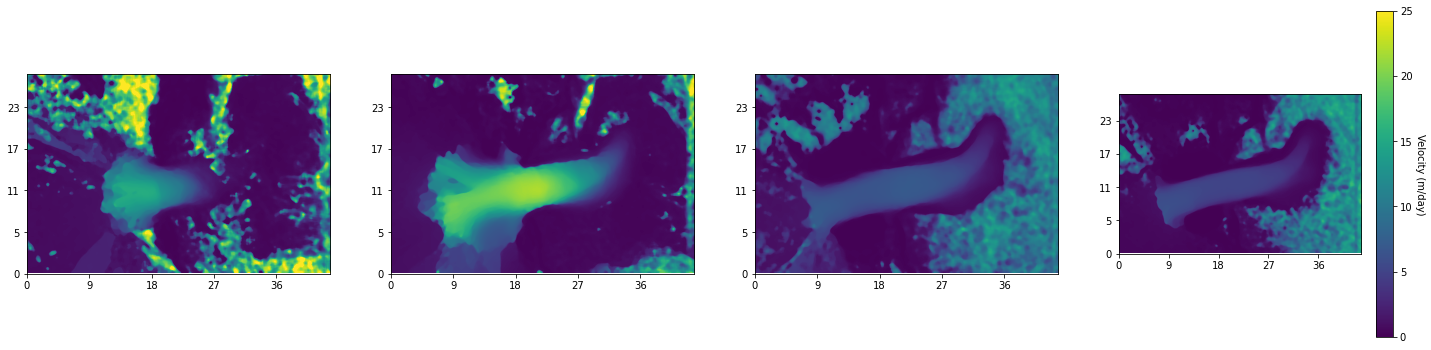

In [4]:
# Load all the velocity field files
path = 'velocity_data/'
years_list = [2015, 2016, 2017, 2018]

img15 = rasterio.open(path + 'median_2015_cleaned2.tif')
img16 = rasterio.open(path + 'median_2016_cleaned2.tif')
img17 = rasterio.open(path + 'median_2017.tif')
img18 = rasterio.open(path + 'median_2018.tif')

# Median-filter images to remove edge peaks (20 pixel filter)
img15_filt = ndimage.median_filter(img15.read(1), 20)
img16_filt = ndimage.median_filter(img16.read(1), 20)
img17_filt = ndimage.median_filter(img17.read(1), 20)
img18_filt = ndimage.median_filter(img18.read(1), 20)

# Plot annual velocity fields
plt.figure(figsize=(25,6))
ax1 = plt.subplot(141)
plt.imshow(img15_filt)
plt.xticks([0, 300, 600, 900, 1200],[0, int(300*0.03), int(600*0.03), int(900*0.03), int(1200*0.03)])
plt.yticks([160, 360, 560, 760, 960],[round(760*0.03), round(560*0.03), round(360*0.03), round(160*0.03), int(0*0.03)])
plt.clim(0,25)
ax2 = plt.subplot(142)
plt.imshow(img16_filt)
plt.xticks([0, 300, 600, 900, 1200],[0, int(300*0.03), int(600*0.03), int(900*0.03), int(1200*0.03)])
plt.yticks([160, 360, 560, 760, 960],[round(760*0.03), round(560*0.03), round(360*0.03), round(160*0.03), int(0*0.03)])
plt.clim(0,25)
ax3 = plt.subplot(143)
plt.imshow(img17_filt)
plt.xticks([0, 300, 600, 900, 1200],[0, int(300*0.03), int(600*0.03), int(900*0.03), int(1200*0.03)])
plt.yticks([160, 360, 560, 760, 960],[round(760*0.03), round(560*0.03), round(360*0.03), round(160*0.03), int(0*0.03)])
plt.clim(0,25)
ax4 = plt.subplot(144)
plt.imshow(img18_filt)
plt.xticks([0, 300, 600, 900, 1200],[0, int(300*0.03), int(600*0.03), int(900*0.03), int(1200*0.03)])
plt.yticks([160, 360, 560, 760, 960],[round(760*0.03), round(560*0.03), round(360*0.03), round(160*0.03), int(0*0.03)])
plt.clim(0,25)
cbar = plt.colorbar()
cbar.set_label('Velocity (m/day)', labelpad=12, rotation=270)

## Evaluate transect velocity
We  estimate transect velocity profiles perpendicular to the ice flow direction, and try to infer the stress exponent that explain best the velocity transect shapes.

In [5]:
# Define the profile coordinates:
x0, y0 = 650, 435
x1, y1 = 690, 670

# Velocity profiles of the different years
u15 = profile_line(img15_filt, (y0, x0), (y1, x1))
u16 = profile_line(img16_filt, (y0, x0), (y1, x1))
u17 = profile_line(img17_filt, (y0, x0), (y1, x1))
u18 = profile_line(img18_filt, (y0, x0), (y1, x1))

# Original y vector
ybis   = np.linspace(-len(u15)/2*30, len(u15)/2*30-30, len(u15))
y      = np.linspace(-len(u16)/2*30, len(u16)/2*30-30, len(u16))
y_plot = np.linspace(-len(u16)/2*30/1000, (len(u16)/2*30-30)/1000, len(u16))


# Find U_0 for each year
u0_15, idx15 = np.max(u15), np.argmax(u15)
u0_16, idx16 = np.max(u16), np.argmax(u16)
u0_17, idx17 = np.max(u17), np.argmax(u17)
u0_18, idx18 = np.max(u18), np.argmax(u18)

## Plot surface velocity images and transects

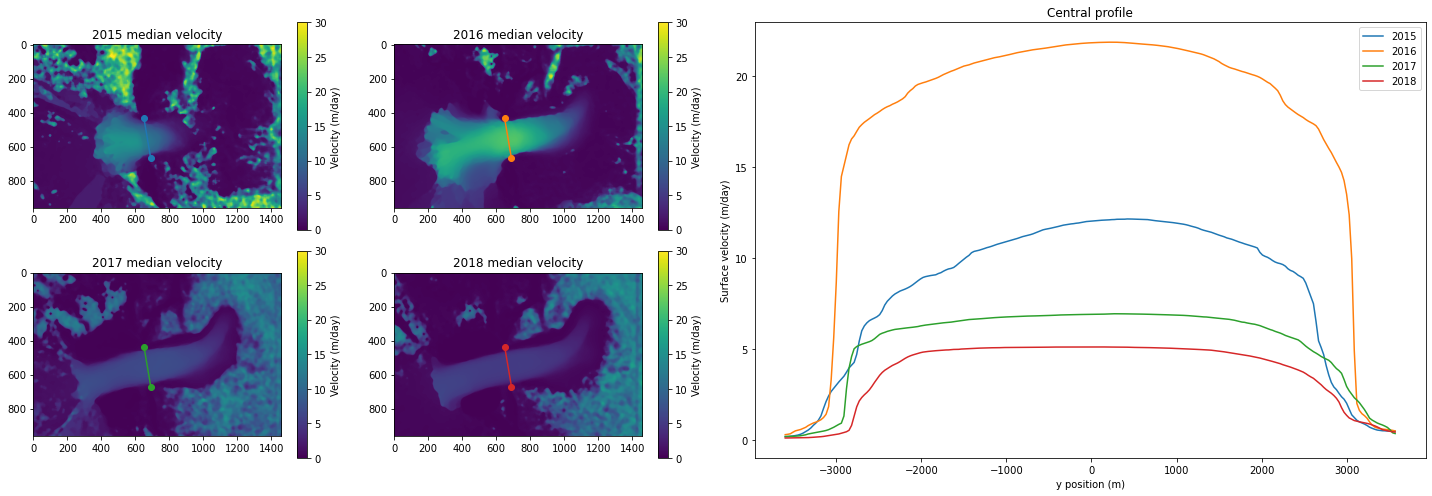

In [6]:
fig = plt.figure(figsize=(20,7))
gs = gridspec.GridSpec(2, 4)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# --- Small subplots ---
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(img15_filt, vmin=0, vmax=30)
ax1.plot([x0, x1], [y0, y1], 'o-', color=colors[0])
ax1.set_title('2015 median velocity')
fig.colorbar(im1, ax=ax1, label='Velocity (m/day)')

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(img16_filt, vmin=0, vmax=30)
ax2.plot([x0, x1], [y0, y1], 'o-', color=colors[1])
ax2.set_title('2016 median velocity')
fig.colorbar(im2, ax=ax2, label='Velocity (m/day)')

ax3 = fig.add_subplot(gs[1, 0])
im3 = ax3.imshow(img17_filt, vmin=0, vmax=30)
ax3.plot([x0, x1], [y0, y1], 'o-', color=colors[2])
ax3.set_title('2017 median velocity')
fig.colorbar(im3, ax=ax3, label='Velocity (m/day)')

ax4 = fig.add_subplot(gs[1, 1])
im4 = ax4.imshow(img18_filt, vmin=0, vmax=30)
ax4.plot([x0, x1], [y0, y1], 'o-', color=colors[3])
ax4.set_title('2018 median velocity')
fig.colorbar(im4, ax=ax4, label='Velocity (m/day)')

ax_big = fig.add_subplot(gs[:, 2:])
ax_big.plot(y, u15)
ax_big.plot(y, u16)
ax_big.plot(y, u17)
ax_big.plot(y, u18)
ax_big.set_xlabel("y position (m)")
ax_big.set_ylabel('Surface velocity (m/day)')
ax_big.set_title('Central profile')
ax_big.legend(['2015','2016','2017','2018'])
plt.tight_layout()

# Complex model: invert n (stress exponent) & w (half-width)

## Run the inversion

In [7]:
# Choose velocity year to study and parameters
year = '2015'                                   # select year
U_VEC = u15                                     # select the velocity profile
U_0 = u0_15                                     # select the max velocity
ERR = np.ones((len(U_VEC))) #err15              # select error vector (variance profiles). To inverse without error, put ERR = np.ones((len(U_VEC)))
Y_VEC = y                                       # select the y vector

# Run the inversion
n_list = np.linspace(0,12,61).round(2)                                               # list of stress exponent
w_list = np.linspace(2100,3900,61)                                                  # list of half-width  85*30 - 145*30
RES = np.empty((len(w_list), len(n_list)))                                          # initialize residuals matrix
VR = np.empty((len(w_list), len(n_list)))                                           # initialize variance matrix
i = 0

for w in w_list:                                                                    # loop over the half-width
    U_DATA = U_VEC[np.where((Y_VEC >= -w) & (Y_VEC <= w))]                          # limit the real velocity profile to the same width modeled
    ERR_ = ERR[np.where((Y_VEC >= -w) & (Y_VEC <= w))]                              # limit the data error profile to the same width modeled
    if int(2*w/30) > len(U_DATA):                                                   # check if tested half-width is > (len(data) / 2)
        reduc_coef = ((int(2*w/30) - len(U_DATA))*30) / 2                           # estimate a reduction coefficient 
        Y_MODEL = np.linspace(-w+reduc_coef,w-reduc_coef,int(len(U_DATA)))          # define Y vector for modeled velocity with reduced length (remove the part out or range)   int(len(U_DATA))
    else:
        Y_MODEL = np.linspace(-w,w,int(len(U_DATA)))                                # define Y vector for modeled velocity
    j = 0
    for n in n_list:                                                                # loop over stress exponent
        U_MODEL = ice_velocity(U_0, Y_MODEL, w, n)                                  # calcul of the modeled velocity profile
        RES[i,j] = L2_norm_residuals(U_DATA,U_MODEL, ERR_)                          # estimate L2-norm resiudals btw real and modeled velocity
        j += 1
    i += 1

print(f'Min residual for {year}: {np.min(RES)}')

Min residual for 2015: 0.7205833890138602


## Residuals and best model

Best parameter pair: n=2.00, w=3300 (misfit: 0.72)
Threshold used: 0.76


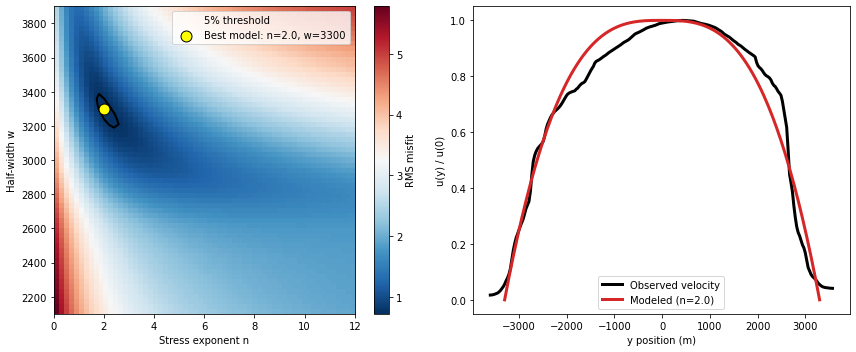

In [9]:
# Find best model
min_misfit = np.min(RES)
idx_min = np.argwhere(RES == min_misfit)

best_w = w_list[idx_min[0,0]]
best_n = n_list[idx_min[0,1]]

# Define threshold (5% above min)
threshold = min_misfit * 1.05

# Create meshgrid for proper axes
N, W = np.meshgrid(n_list, w_list)

# --- Plot residuals ---
plt.figure(figsize=(12,5))
plt.subplot(121)
im = plt.imshow(RES, cmap='RdBu_r', origin='lower', extent=[n_list.min(), n_list.max(), w_list.min(), w_list.max()], aspect='auto')
CS = plt.contour(N, W, RES, levels=[threshold], colors='black', linewidths=2)
CS.collections[0].set_label('5% threshold')
plt.scatter(best_n, best_w, s=120, color='yellow', edgecolor='black', zorder=5, label=f'Best model: n={round(best_n,1)}, w={round(best_w)}')
plt.xlabel('Stress exponent n')
plt.ylabel('Half-width w')
plt.legend()
plt.colorbar(im, label='RMS misfit')

# --- Compute best model profile ---
U_DATA = U_VEC[np.where((Y_VEC >= -best_w) & (Y_VEC <= best_w))]
Y_MODEL = np.linspace(-best_w, best_w, len(U_DATA))
U_BEST_MODEL = ice_velocity(U_0, Y_MODEL, best_w, best_n)

# --- Plot velocity profile ---
plt.subplot(122)
plt.plot(Y_VEC, U_VEC/U_0, color='k', linewidth=3, label='Observed velocity')
plt.plot(Y_MODEL, U_BEST_MODEL/U_0, color='C3', linewidth=3, label=f'Modeled (n={round(best_n,1)})')
plt.xlabel('y position (m)')
plt.ylabel('u(y) / u(0)')
plt.legend()

# --- Print results ---
print(f'Best parameter pair: n={best_n:.2f}, w={round(best_w)} (misfit: {min_misfit:.2f})')
print(f'Threshold used: {threshold:.2f}')
plt.tight_layout()